In [1]:
# Cell 1 — Imports & Environment
from dotenv import load_dotenv
import os
load_dotenv(r'C:\Users\Gurveer\ds-portfolio\.env')
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

from pydantic import BaseModel, Field
from typing_extensions import TypedDict, Literal, Annotated
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.prebuilt import create_react_agent
from langgraph.types import Command
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")
llm = init_chat_model("openai:gpt-4o-mini")
print("GPT-4o-mini loaded")

c:\Users\Gurveer\anaconda3\envs\ds-portfolio\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful
GPT-4o-mini loaded


In [2]:
# Cell 2 — User Profile & Triage Rules
profile = {
    "name": "Gurveer",
    "full_name": "Gurveer Sidhu",
    "user_profile_background": (
        "Data Science student at Wentworth Institute of Technology. "
        "Working on AI/ML portfolio projects targeting roles at "
        "Anthropic, Meta, Amazon, Fidelity, Delta, and United Airlines."
    ),
}

prompt_instructions = {
    "triage_rules": {
        "ignore":  "Marketing newsletters, spam, unsolicited promotions",
        "notify":  "Project status updates, system notifications, FYI emails",
        "respond": "Direct questions from teammates, meeting requests, "
                   "critical bug reports, professor or advisor messages",
    },
    "agent_instructions": (
        "You are Gurveer's AI assistant. Help manage emails efficiently. "
        "Be concise, professional, and helpful."
    )
}

print("Profile configured:")
print(f"  Name:       {profile['full_name']}")
print(f"  Background: {profile['user_profile_background'][:60]}...")

Profile configured:
  Name:       Gurveer Sidhu
  Background: Data Science student at Wentworth Institute of Technology. W...


In [3]:
# Cell 3 — Triage System & User Prompts
triage_system_prompt = """You are an email triage assistant for {full_name}.

Background: {user_profile_background}

Classify each email into exactly one category:
- ignore:  {triage_no}
- notify:  {triage_notify}  
- respond: {triage_email}

Think step by step before classifying."""

triage_user_prompt = """Please triage this email:

From:    {author}
To:      {to}
Subject: {subject}

Body:
{email_thread}"""

print("Prompt templates defined")

Prompt templates defined


In [4]:
# Cell 4 — Router Model (Structured Output)
class Router(BaseModel):
    """Classify an email and explain the reasoning."""
    reasoning: str = Field(
        description="Step-by-step reasoning behind the classification."
    )
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="ignore = irrelevant, notify = FYI only, respond = needs reply"
    )

llm_router = llm.with_structured_output(Router)
print("Router model ready with structured output")

Router model ready with structured output


In [5]:
# Cell 5 — Agent Tools
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    return f"Email sent to {to} with subject '{subject}'"

@tool
def schedule_meeting(
    attendees: list[str],
    subject: str,
    duration_minutes: int,
    preferred_day: str
) -> str:
    """Schedule a calendar meeting."""
    return (f"Meeting '{subject}' scheduled for {preferred_day} "
            f"({duration_minutes} min) with {', '.join(attendees)}")

@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    return f"Available slots on {day}: 10:00 AM, 2:00 PM, 4:00 PM"

tools = [write_email, schedule_meeting, check_calendar_availability]
print(f"Tools registered: {[t.name for t in tools]}")

Tools registered: ['write_email', 'schedule_meeting', 'check_calendar_availability']



LangGraph agent compiled successfully


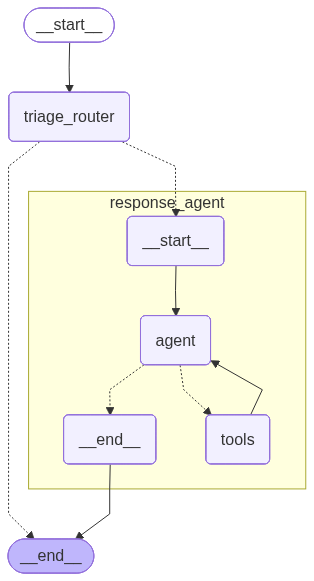

In [6]:
# Cell 6 — Build LangGraph Agent
class State(TypedDict):
    email_input: dict
    messages: Annotated[list, add_messages]

# Response agent using ReAct pattern
response_agent = create_react_agent(llm, tools=tools)

def triage_router(state: State) -> Command[Literal["response_agent", "__end__"]]:
    """Route email to response agent or end based on classification."""
    email = state['email_input']
    
    system_prompt = triage_system_prompt.format(
        full_name=profile["full_name"],
        user_profile_background=profile["user_profile_background"],
        triage_no=prompt_instructions["triage_rules"]["ignore"],
        triage_notify=prompt_instructions["triage_rules"]["notify"],
        triage_email=prompt_instructions["triage_rules"]["respond"],
    )
    user_prompt = triage_user_prompt.format(
        author=email["author"],
        to=email["to"],
        subject=email["subject"],
        email_thread=email["email_thread"],
    )
    
    result = llm_router.invoke([
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": user_prompt},
    ])
    
    icons = {"respond": "📧", "ignore": "🚫", "notify": "🔔"}
    labels = {
        "respond": "RESPOND — drafting reply",
        "ignore":  "IGNORE — skipping",
        "notify":  "NOTIFY — flagging for review"
    }
    print(f"{icons[result.classification]} {labels[result.classification]}")
    print(f"   Reasoning: {result.reasoning[:120]}...")
    
    if result.classification == "respond":
        return Command(
            goto="response_agent",
            update={"messages": [{
                "role": "user",
                "content": (
                    f"{prompt_instructions['agent_instructions']}\n\n"
                    f"Respond to this email:\n{email}"
                )
            }]}
        )
    return Command(goto=END, update=None)

# Compile the graph
email_agent = StateGraph(State)
email_agent.add_node(triage_router)
email_agent.add_node("response_agent", response_agent)
email_agent.add_edge(START, "triage_router")
email_agent = email_agent.compile()

print("\nLangGraph agent compiled successfully")
display(Image(email_agent.get_graph(xray=True).draw_mermaid_png()))

In [7]:
# Cell 7 — Test Case 1: Spam Email (should IGNORE)
spam_email = {
    "author":       "Marketing Team <marketing@amazingdeals.com>",
    "to":           "Gurveer Sidhu <sidhugurveer5@gmail.com>",
    "subject":      "EXCLUSIVE OFFER: 80% OFF Developer Tools!",
    "email_thread": (
        "Don't miss this INCREDIBLE opportunity! "
        "Get 80% OFF Premium Developer Suite — $199/month! "
        "Limited time offer expires in 24 HOURS!"
    ),
}

print("=" * 55)
print("TEST 1: Spam / Marketing Email")
print("=" * 55)
response1 = email_agent.invoke({"email_input": spam_email})

TEST 1: Spam / Marketing Email
🚫 IGNORE — skipping
   Reasoning: This email is from a marketing team promoting a discount on developer tools. It does not require any action or response ...


In [8]:
# Cell 8 — Test Case 2: Technical Question (should RESPOND)
tech_email = {
    "author":       "Alice Smith <alice.smith@company.com>",
    "to":           "Gurveer Sidhu <sidhugurveer5@gmail.com>",
    "subject":      "Quick question about API documentation",
    "email_thread": (
        "Hi Gurveer,\n\n"
        "I was reviewing the API documentation for the new authentication "
        "service and noticed a few endpoints seem to be missing from the specs. "
        "Could you help clarify if this was intentional or if we should update "
        "the docs?\n\n"
        "Specifically:\n- /auth/refresh\n- /auth/validate\n\nThanks!\nAlice"
    ),
}

print("=" * 55)
print("TEST 2: Direct Technical Question")
print("=" * 55)
response2 = email_agent.invoke({"email_input": tech_email})

print("\nAgent response:")
for m in response2["messages"]:
    m.pretty_print()

TEST 2: Direct Technical Question
📧 RESPOND — drafting reply
   Reasoning: The email contains a direct question about API documentation, asking for clarification regarding missing endpoints. This...

Agent response:
================================ Human Message =================================

You are Gurveer's AI assistant. Help manage emails efficiently. Be concise, professional, and helpful.

Respond to this email:
{'author': 'Alice Smith <alice.smith@company.com>', 'to': 'Gurveer Sidhu <sidhugurveer5@gmail.com>', 'subject': 'Quick question about API documentation', 'email_thread': 'Hi Gurveer,\n\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\n\nSpecifically:\n- /auth/refresh\n- /auth/validate\n\nThanks!\nAlice'}
================================== Ai Message ==================================
Tool Calls:
  write_

In [9]:
# Cell 9 — Test Case 3: Meeting Request (should RESPOND with calendar tool)
meeting_email = {
    "author":       "Prof. Johnson <prof.johnson@wit.edu>",
    "to":           "Gurveer Sidhu <sidhugurveer5@gmail.com>",
    "subject":      "Capstone project review meeting",
    "email_thread": (
        "Hi Gurveer,\n\n"
        "I'd like to schedule a 30-minute meeting to review your capstone "
        "project progress. Would Thursday work for you?\n\n"
        "Best,\nProf. Johnson"
    ),
}

print("=" * 55)
print("TEST 3: Meeting Request from Professor")
print("=" * 55)
response3 = email_agent.invoke({"email_input": meeting_email})

print("\nAgent response:")
for m in response3["messages"]:
    m.pretty_print()

TEST 3: Meeting Request from Professor
📧 RESPOND — drafting reply
   Reasoning: The email is from Prof. Johnson, which indicates that it is related to a direct inquiry regarding the scheduling of a me...

Agent response:
================================ Human Message =================================

You are Gurveer's AI assistant. Help manage emails efficiently. Be concise, professional, and helpful.

Respond to this email:
{'author': 'Prof. Johnson <prof.johnson@wit.edu>', 'to': 'Gurveer Sidhu <sidhugurveer5@gmail.com>', 'subject': 'Capstone project review meeting', 'email_thread': "Hi Gurveer,\n\nI'd like to schedule a 30-minute meeting to review your capstone project progress. Would Thursday work for you?\n\nBest,\nProf. Johnson"}
================================== Ai Message ==================================
Tool Calls:
  schedule_meeting (call_KejMZ8sWR1ibA32MpZXHIrq0)
 Call ID: call_KejMZ8sWR1ibA32MpZXHIrq0
  Args:
    attendees: ['Gurveer Sidhu <sidhugurveer5@gmail.com>', 'Pr

In [10]:
# Cell 10 — Summary
print("""
╔══════════════════════════════════════════════════════════╗
║     LangGraph Email Agent — Project Summary              ║
╠══════════════════════════════════════════════════════════╣
║  Framework:    LangGraph StateGraph                      ║
║  LLM:          GPT-4o-mini                               ║
║  Pattern:      Triage Router → ReAct Response Agent      ║
║  Tools:        write_email, schedule_meeting,            ║
║                check_calendar_availability               ║
╠══════════════════════════════════════════════════════════╣
║  Test cases:                                             ║
║  1. Spam email         → IGNORE                          ║
║  2. Technical question → RESPOND + draft reply           ║
║  3. Meeting request    → RESPOND + schedule_meeting tool ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║     LangGraph Email Agent — Project Summary              ║
╠══════════════════════════════════════════════════════════╣
║  Framework:    LangGraph StateGraph                      ║
║  LLM:          GPT-4o-mini                               ║
║  Pattern:      Triage Router → ReAct Response Agent      ║
║  Tools:        write_email, schedule_meeting,            ║
║                check_calendar_availability               ║
╠══════════════════════════════════════════════════════════╣
║  Test cases:                                             ║
║  1. Spam email         → IGNORE                          ║
║  2. Technical question → RESPOND + draft reply           ║
║  3. Meeting request    → RESPOND + schedule_meeting tool ║
╚══════════════════════════════════════════════════════════╝

